# Verified Flip — a minimal convergence check for feature pruning

Re-runs three of the earlier step-size experiments — **single clean feature**, **step-size sweep**, and **blocking by an established feature** — but replaces the raw IDBD $h$-sign-flip rule with the **Verified Flip** judge. Learning is untouched (constant-step-size LMS on the same data and seeds); the judge only *observes* the tracked feature.

**The idea.** An $h$-flip is a *claim* of convergence, not a verdict. The weight is the exact integral of every past gradient, so it remembers what the flipped trace has just forgotten. At each flip — *gated so that at most one check happens per window* — we verify the claim against the weight itself: *since the last check, has the weight moved by more than its own jitter can explain?*

$$T = z^\star \sqrt{\alpha_{\mathrm{eff}}\, \hat q / \hat s^2}, \qquad D = w - w_{\mathrm{mark}}$$

- $|D| > T$ → **veto** (weight still moving beyond noise): keep protection, re-anchor $w_{\mathrm{mark}} \leftarrow w$, **double the patience** $P$.
- $2|D| \le T$ → **certified** (even a doubled window provably can't veto): release protection; for the blocking case compare $|w|$ to the established weight (tenure / prune).
- otherwise → **grow**: **double the patience** $P$, keep the anchor, wait for more displacement to accumulate.

**Pacing / the window.** A check fires only when `t - t_last >= P / (alpha_eff * s2_hat)`. The window $P/(\alpha_{\mathrm{eff}}\hat s^2)$ is $P$ *adaptation-times* (with $P=1$, one adaptation-time $1/(\alpha_{\mathrm{eff}}\,\mathbb E[\varphi^2])$ — the LMS/IDBD response time-constant). $h$ flips many times inside one window once the weight is near-settled or blocked; checking on *every* flip would re-test the same noise-dominated state and manufacture false vetoes, so we allow **at most one check per window** and each veto/grow **doubles the window** (that is what the horizon bars show — length $\propto P$; the `P…` labels above each check give the value).

**Constants** (all dimensionless, fixed across step-sizes and noise levels): $z^\star = 2.5$ (significance of the jitter test), patience growth $=2$. $\alpha_{\mathrm{eff}} = 2\cdot\texttt{step\_size}$ because the code updates $w \mathrel{-}= \texttt{step\_size}\cdot(2\,\mathrm{error}\,\varphi)$, i.e. $w \mathrel{+}= \alpha_{\mathrm{eff}}\,g$ with $g=-\mathrm{error}\cdot\varphi = \delta\varphi$.

**Beta-free trackers.** The scale trackers no longer use a fixed EMA rate. Their gain is *slaved to the learned window*, $\lambda = \min(\alpha_{\mathrm{eff}}\varphi^2 / P,\, 1)$, and bias is removed exactly with a running product $b \leftarrow b\,(1-\lambda)$ (so $\hat q = q/(1-b)$, $\hat s^2 = s^2/(1-b)$). There is no `beta` hyper-parameter and no tolerance hyper-parameter: the threshold is the weight's own noise floor and the horizon scales with the step-size automatically ($\alpha$-slaving).

**What each plot shows.**
- **Left axis** (true weight scale): the weight(s), the optimal weight (dashed), and the $w_{\mathrm{mark}} \pm T$ **jitter band** (shaded) with its anchor line.
- **Right axis** (normalized): the $h$ **flip indicator**, its raw sign-flips (faint rug), the gated **checks** (△ veto, | grow, ○ certified) each labelled with the patience $P$ *after* that check, sitting above the **pacing horizon** (window bars, length $\propto P$), the first raw $h$ flip (dotted, the *old* rule), and the **verdict** (the first certified check, drawn as the vertical line).
- After the first certification the judge keeps watching in the background — faint **shadow** checks — so we can see whether a slow drift the early verdict *missed* would later have been vetoed. Every check (including certified ones) doubles or holds $P$, so each $P$-doubling has a visible marker.

In [1]:
%matplotlib inline
import sys
from math import sqrt

# make `shared` importable regardless of the notebook's working directory
_SHARED_DIR = '/home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/step_size_analysis'
if _SHARED_DIR not in sys.path:
    sys.path.insert(0, _SHARED_DIR)

import numpy as np
import matplotlib.pyplot as plt

from shared import (
    make_problem_data, optimal_weight, _norm_peak,
    W_COLOR, H_IDBD3_COLOR, W_TEACHER, INCUMBENT_NOISE,
)

# --- Verified-Flip constants (dimensionless, fixed across step-sizes / noise) ---
Z_STAR  = 2.5     # significance level of the jitter test
GROWTH  = 2.0     # patience-doubling factor
BURN_IN = 10      # ignore h flips before this per-feature age

# --- plot colours ---
BAND_COLOR   = '#9923DC'   # w_mark +/- T jitter band + anchor
VETO_COLOR   = '#FF8C00'   # veto check
GROW_COLOR   = '#029999'   # grow / inconclusive check
CERT_COLOR   = '#2E8B57'   # certified / tenure (kept)
PRUNE_COLOR  = '#CC2222'   # certified -> prune
HORIZON_GREY = '0.45'

In [2]:
def run_verified_flip(features, y, step_size, w_init=None, *,
                      z_star=Z_STAR, growth=GROWTH, burn_in=BURN_IN,
                      keep_watching=True):
    """Constant-step-size LMS with the Verified-Flip judge OBSERVING the tracked
    (last) feature. beta-free trackers: the tracker gain lam is slaved to the
    learned window (lam = min(alpha_eff*phi^2/P, 1)); bias is removed with the
    running product b. alpha_eff = 2*step_size."""
    n_steps, n_feat = features.shape
    assert n_feat in (1, 2)
    tracked = n_feat - 1
    w = [0.0] * n_feat if w_init is None else [float(v) for v in w_init]
    alpha_eff = 2.0 * step_size

    phi_col = np.ascontiguousarray(features[:, tracked], dtype=np.float64)
    est_col = np.ascontiguousarray(features[:, 0], dtype=np.float64) if n_feat == 2 else None
    y = np.ascontiguousarray(y, dtype=np.float64)

    w_mark = w[tracked]; P = 1.0; t_last = 0
    q = 0.0; s2 = 0.0; h = 0.0; t = 0; b = 1.0     # b = bias remainder (starts 1)
    q_hat = s2_hat = 0.0
    verdict = None
    events = []; flip_steps = []; window_segs = []; first_h_flip = None

    w_inc_hist = np.empty(n_steps, np.float32)
    w_est_hist = np.empty(n_steps, np.float32) if n_feat == 2 else None
    h_hist = np.empty(n_steps, np.float32)
    wmark_hist = np.empty(n_steps, np.float32)
    T_hist = np.empty(n_steps, np.float32)
    P_hist = np.empty(n_steps, np.float32)

    for i in range(n_steps):
        phi = phi_col[i]
        if n_feat == 2:
            fe = est_col[i]; yhat = w[0] * fe + w[1] * phi
        else:
            yhat = w[0] * phi
        error = yhat - y[i]

        if phi != 0.0:                               # judge observes this step
            t += 1
            g = -error * phi                         # delta * phi, delta = y - yhat
            lam = alpha_eff * phi * phi / P          # tracker gain, slaved to window
            if lam > 1.0:
                lam = 1.0
            q += lam * (g * g - q)                   # 2nd moment of gradient signal
            s2 += lam * (phi * phi - s2)             # 2nd moment of the input
            b *= (1.0 - lam)                         # bias remainder (b -> 0 quickly)
            h_prev = h
            keep = 1.0 - alpha_eff * phi * phi       # IDBD h-trace (read-only)
            if keep < 0.0:
                keep = 0.0
            h = h * keep + g
            denom = 1.0 - b
            if denom > 0.0:
                q_hat = q / denom; s2_hat = s2 / denom

            flipped = (t > burn_in and h_prev != 0.0 and h != 0.0
                       and (h_prev > 0.0) != (h > 0.0))
            if flipped:
                flip_steps.append(i)
                if first_h_flip is None:
                    first_h_flip = i

            settled = verdict is not None
            if flipped and s2_hat > 0.0 and (keep_watching or not settled):
                window = P / (alpha_eff * s2_hat)    # pacing gate
                if (t - t_last) >= window:
                    T = z_star * sqrt(alpha_eff * q_hat / s2_hat)
                    w_now = w[tracked]; D = w_now - w_mark; adD = abs(D)
                    mark_before = w_mark
                    if adD > T:                                  # weight moved: veto
                        outcome = 'veto'; P *= growth; w_mark = w_now; t_last = t
                    elif 2.0 * adD <= T:                         # provably done: certify
                        outcome = 'certified'
                        if not settled:                          # first cert = verdict
                            if n_feat == 2:
                                kind = 'tenure' if abs(w_now) >= abs(w[0]) else 'prune'
                            else:
                                kind = 'certified'
                            verdict = dict(step=i, kind=kind, w=w_now, P=P)
                        else:
                            P *= growth; t_last = t              # shadow: treat as grow
                    else:                                        # unresolved: grow
                        outcome = 'grow'; P *= growth; t_last = t
                    new_window = P / (alpha_eff * s2_hat)
                    window_segs.append((i, i + new_window, outcome, P))
                    events.append(dict(step=i, outcome=outcome, w=w_now,
                                       w_mark=mark_before, T=T, P=P, D=D,
                                       shadow=settled))

        if n_feat == 2:
            w[0] -= step_size * (2.0 * error * fe)
            w[1] -= step_size * (2.0 * error * phi)
        else:
            w[0] -= step_size * (2.0 * error * phi)

        w_inc_hist[i] = w[tracked]
        if n_feat == 2:
            w_est_hist[i] = w[0]
        h_hist[i] = h
        wmark_hist[i] = w_mark
        T_hist[i] = z_star * sqrt(alpha_eff * q_hat / s2_hat) if s2_hat > 0.0 else np.nan
        P_hist[i] = P

    # nominal protected-childhood window from the MATURE input scale (not the
    # noisy first sample), for display only:
    window0 = 1.0 / (alpha_eff * s2_hat) if s2_hat > 0.0 else np.nan

    return dict(w_inc=w_inc_hist, w_est=w_est_hist, h=h_hist, wmark=wmark_hist,
                T=T_hist, P=P_hist, events=events,
                flip_steps=np.asarray(flip_steps, int),
                first_h_flip=first_h_flip, verdict=verdict, window_segs=window_segs,
                alpha_eff=alpha_eff, n_feat=n_feat, window0=window0)

In [3]:
def _logsub(n, k=4000):
    if n <= k:
        return np.arange(n)
    idx = np.unique(np.round(np.geomspace(1, n, k)).astype(int)) - 1
    return idx[(idx >= 0) & (idx < n)]


def plot_vf_panel(ax, r, *, w_opt, title, log_x=True):
    n = len(r['w_inc'])
    steps = np.arange(1, n + 1)
    sub = _logsub(n)
    xs = steps[sub]
    ax2 = ax.twinx()

    # ---------- right axis: h indicator, flips, checks, pacing horizon, P ----------
    h = r['h'].astype(float)
    ax2.plot(xs, _norm_peak(h)[sub], color=H_IDBD3_COLOR, lw=0.7, alpha=0.35,
             label='$h$ trace (flip indicator)', zorder=2)
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    if len(r['flip_steps']):
        ax2.vlines(r['flip_steps'] + 1, -1.13, -1.0, color='0.5', lw=0.5,
                   alpha=0.08, zorder=1)

    # protected childhood: from 1 to the first check (or the nominal window if none)
    v_step = r['verdict']['step'] if r['verdict'] is not None else np.inf
    if r['window_segs']:
        protected_end = r['window_segs'][0][0] + 1
    else:
        protected_end = min(r['window0'], n) if np.isfinite(r['window0']) else n
    ax2.hlines(0.86, 1, protected_end, color=HORIZON_GREY, lw=1.8, alpha=0.5,
               zorder=3, label='pacing horizon (window $\\propto P$)')

    seg_color = {'veto': VETO_COLOR, 'grow': GROW_COLOR, 'certified': CERT_COLOR}
    for (t0, t1, oc, Pval) in r['window_segs']:
        shadow = t0 > v_step
        ax2.hlines(0.86, t0 + 1, min(t1 + 1, n), color=seg_color.get(oc, HORIZON_GREY),
                   lw=(1.2 if shadow else 1.8), alpha=(0.22 if shadow else 0.6), zorder=3)

    # check markers + patience (P) labels. Every check (veto / grow / certified)
    # is drawn so each P-doubling has a visible marker; shadow (post-verdict)
    # checks are faint. The certified check that IS the verdict also gets the
    # vertical verdict line below.
    mark = {'veto': ('^', VETO_COLOR, 'veto check', 75),
            'grow': ('|', GROW_COLOR, 'grow check', 75),
            'certified': ('o', CERT_COLOR, 'certified check', 34)}
    seen = set()
    for e in r['events']:
        m, c, lab, ms = mark[e['outcome']]
        shadow = e['shadow']
        a = 0.35 if shadow else 1.0
        ax2.scatter(e['step'] + 1, 1.05, marker=m, s=ms, color=c, alpha=a,
                    zorder=12, clip_on=False, label=(lab if lab not in seen else None))
        seen.add(lab)
        ax2.annotate(f"$P${e['P']:.0f}", xy=(e['step'] + 1, 1.05),
                     xytext=(0, 7), textcoords='offset points', ha='center',
                     fontsize=6.5, color=c, alpha=(0.5 if shadow else 0.95),
                     clip_on=False, zorder=13)

    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('flip indicator\n(normalized)', fontsize=14)

    # ---------- left axis: weights + jitter band ----------
    finiteT = r['T'][np.isfinite(r['T']) & (r['T'] > 0)]
    band = float(np.nanmedian(finiteT)) if finiteT.size else 0.05
    wmark = r['wmark'].astype(float); T = r['T'].astype(float)
    ax.fill_between(xs, (wmark - T)[sub], (wmark + T)[sub], color=BAND_COLOR,
                    alpha=0.13, lw=0, zorder=4,
                    label='$w_{\\mathrm{mark}} \\pm T$ (jitter band)')
    ax.plot(xs, wmark[sub], color=BAND_COLOR, ls=(0, (3, 2)), lw=1.0, alpha=0.7,
            zorder=5, label='$w_{\\mathrm{mark}}$ (anchor)')

    ax.plot(xs, r['w_inc'][sub], color=W_COLOR, lw=2.0, zorder=10,
            label='incumbent weight')
    if r['n_feat'] == 2:
        ax.plot(xs, r['w_est'][sub], color=W_COLOR, lw=2.0, alpha=0.3, zorder=10,
                label='established weight')
    if w_opt is not None:
        ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, zorder=9,
                   label='optimal weight')

    if r['first_h_flip'] is not None:
        ax2.axvline(r['first_h_flip'] + 1, color=H_IDBD3_COLOR, ls=':', lw=1.6,
                    zorder=8, label='first $h$ flip (raw rule)')
    if r['verdict'] is not None:
        v = r['verdict']
        col = PRUNE_COLOR if v['kind'] == 'prune' else CERT_COLOR
        ax2.axvline(v['step'] + 1, color=col, lw=2.0, zorder=8,
                    label=f"verdict: {v['kind']}")
        frac = np.log(v['step'] + 1) / np.log(n)
        yv = w_opt * 0.5 if (w_opt is not None and w_opt > 0) else band
        ax.annotate(f"{v['kind']} @ {v['step']:,}\n$|w|$={abs(v['w']):.3f}, $P$={v['P']:.0f}",
                    xy=(v['step'] + 1, yv),
                    xytext=(-8 if frac > 0.55 else 8, 0), textcoords='offset points',
                    ha='right' if frac > 0.55 else 'left', va='center',
                    fontsize=10, color=col, zorder=20)

    if log_x:
        ax.set_xscale('log')
    wo = abs(w_opt) if w_opt is not None else 0.0
    ymax = max(1.3 * wo, 3.0 * band)
    ax.set_ylim(-0.35 * ymax, 1.08 * ymax)
    ax.set_ylabel('weight', fontsize=14)
    ax.set_title(title, fontsize=13)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    return ax2


def stack_panels(results, titles, *, w_opts, suptitle, log_x=True,
                 figsize_w=11.5, panel_h=3.4):
    n = len(results)
    if np.ndim(w_opts) == 0:
        w_opts = [w_opts] * n
    fig, axes = plt.subplots(n, 1, figsize=(figsize_w, panel_h * n),
                             sharex=True, squeeze=False)
    axes = axes[:, 0]
    all_ax = []
    for ax, r, ttl, wo in zip(axes, results, titles, w_opts):
        ax2 = plot_vf_panel(ax, r, w_opt=wo, title=ttl, log_x=log_x)
        all_ax.append((ax, ax2))
    axes[-1].set_xlabel('step (log scale)' if log_x else 'step', fontsize=15)
    fig.suptitle(suptitle, fontsize=17)
    seen, H, L = set(), [], []
    for a in list(axes) + [a2 for _, a2 in all_ax]:
        for hh, ll in zip(*a.get_legend_handles_labels()):
            if ll and ll not in seen:
                seen.add(ll); H.append(hh); L.append(ll)
    fig.legend(H, L, loc='upper center', ncol=4, fontsize=10.5,
               bbox_to_anchor=(0.5, 1.005 + 0.16 / n))
    fig.tight_layout(rect=(0, 0, 1, 0.965))
    return fig


def print_summary(tags, results):
    print(f"{'case':>26} | {'h flip':>7} | {'veto':>4} {'grow':>4} | verdict")
    print('-' * 88)
    for tag, r in zip(tags, results):
        nv = sum(1 for e in r['events'] if e['outcome'] == 'veto' and not e['shadow'])
        ng = sum(1 for e in r['events'] if e['outcome'] == 'grow' and not e['shadow'])
        v = r['verdict']
        vs = (f"{v['kind']} @ {v['step']:,} (|w|={abs(v['w']):.3f}, P={v['P']:.0f})"
              if v else "no verdict (protected childhood)")
        print(f"{tag:>26} | {str(r['first_h_flip']):>7} | {nv:>4} {ng:>4} | {vs}")

## Experiment 1 — single clean feature (ideal-weight sweep)

One clean feature learned from a zero weight with LMS (step-size 0.01, 10k steps); the target carries $\sigma=0.1$ noise. The optimal weight is swept. **Expected:** the method should be *invisible* — the first genuine $h$ flip **is** convergence, and the check certifies right around it (the verdict tracks the flip). Near-zero-weight features certify at $\approx 0$ (settled within their own jitter band).

                      case |  h flip | veto grow | verdict
----------------------------------------------------------------------------------------
                      w*=1 |     967 |    1    0 | certified @ 1,185 (|w|=0.996, P=2)
                    w*=0.5 |     706 |    1    0 | certified @ 962 (|w|=0.487, P=2)
                    w*=0.1 |     668 |    1    0 | certified @ 847 (|w|=0.090, P=2)
                   w*=0.01 |      15 |    0    0 | certified @ 241 (|w|=0.007, P=1)
                  w*=0.001 |      14 |    0    0 | certified @ 107 (|w|=0.002, P=1)
                      w*=0 |      14 |    0    0 | certified @ 78 (|w|=0.001, P=1)


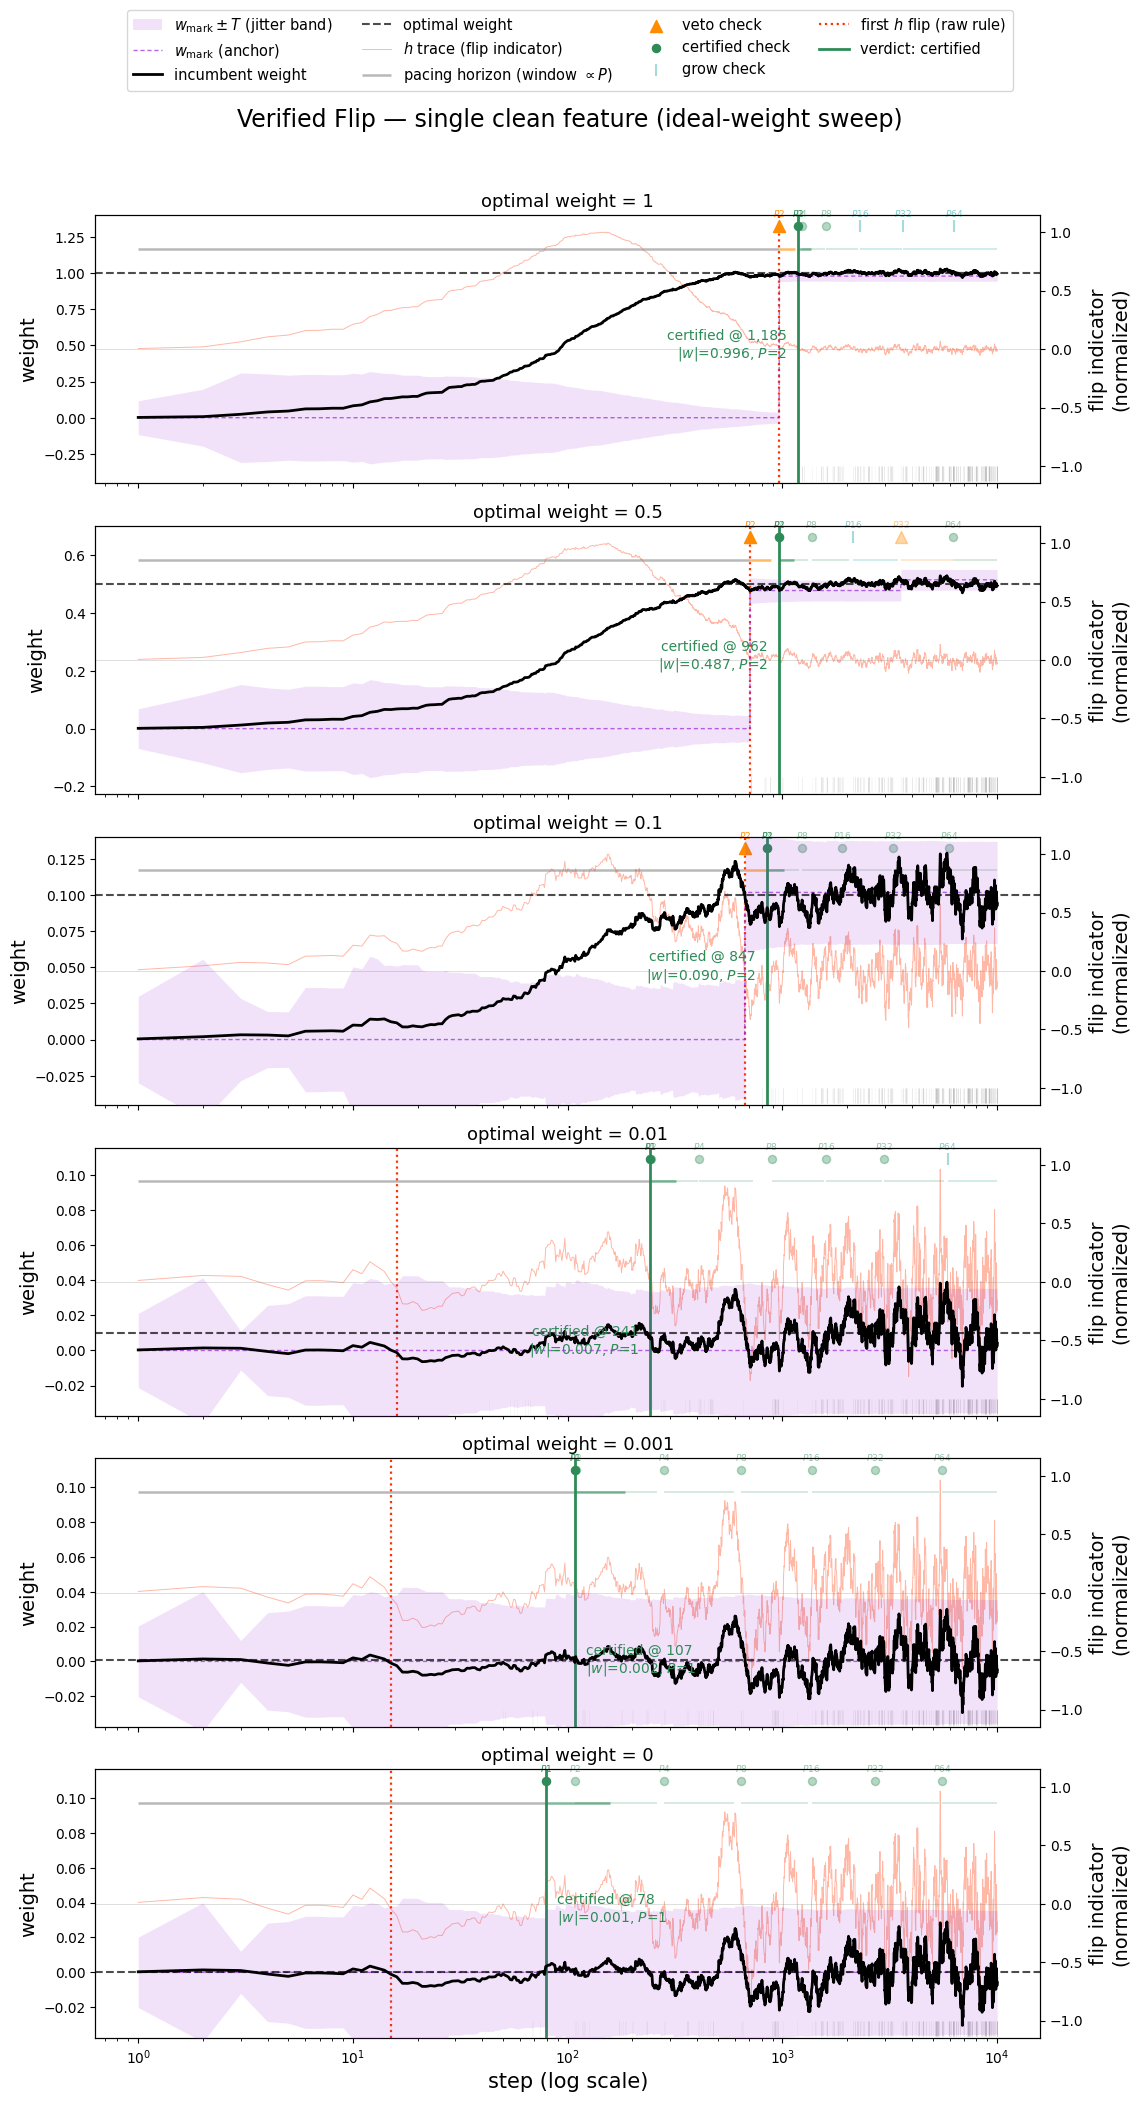

In [4]:
N_STEPS_1 = 10_000
IDEAL_WEIGHTS = [1.0, 0.5, 0.1, 0.01, 0.001, 0.0]

res1, titles1, wopts1 = [], [], []
for w_ideal in IDEAL_WEIGHTS:
    feats, targ = make_problem_data(N_STEPS_1, [w_ideal], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    res1.append(run_verified_flip(feats, targ, step_size=0.01))
    titles1.append(f'optimal weight = {optimal_weight(w_ideal, 0.0):g}')
    wopts1.append(optimal_weight(w_ideal, 0.0))

print_summary([f'w*={w:g}' for w in IDEAL_WEIGHTS], res1)
fig = stack_panels(res1, titles1, w_opts=wopts1,
                   suptitle='Verified Flip — single clean feature (ideal-weight sweep)')
plt.show()

## Experiment 2 — step-size sweep ($\alpha$-slaving regression test)

The same single clean feature (optimal weight $0.5$), now with the step-size swept over six orders of magnitude, **no constant changed**, 1M steps. **Expected:** identical behaviour at every step-size, merely rescaled in time — the verdict should track the $h$ flip and its timing should scale like $1/\alpha$ (the adaptation time). The smallest step-sizes never reach their first flip inside the fixed 1M-step budget (the whole timeline, horizon included, scales with $\alpha$), which is the correct $\alpha$-slaved outcome, not a failure.

                      case |  h flip | veto grow | verdict
----------------------------------------------------------------------------------------
                   ss=0.01 |    1151 |    1    0 | certified @ 1,349 (|w|=0.501, P=2)
                  ss=0.001 |   12392 |    1    0 | certified @ 14,644 (|w|=0.497, P=2)
                 ss=0.0001 |  128384 |    1    0 | certified @ 145,332 (|w|=0.500, P=2)
                  ss=1e-05 |    None |    0    0 | no verdict (protected childhood)
                  ss=1e-06 |    None |    0    0 | no verdict (protected childhood)


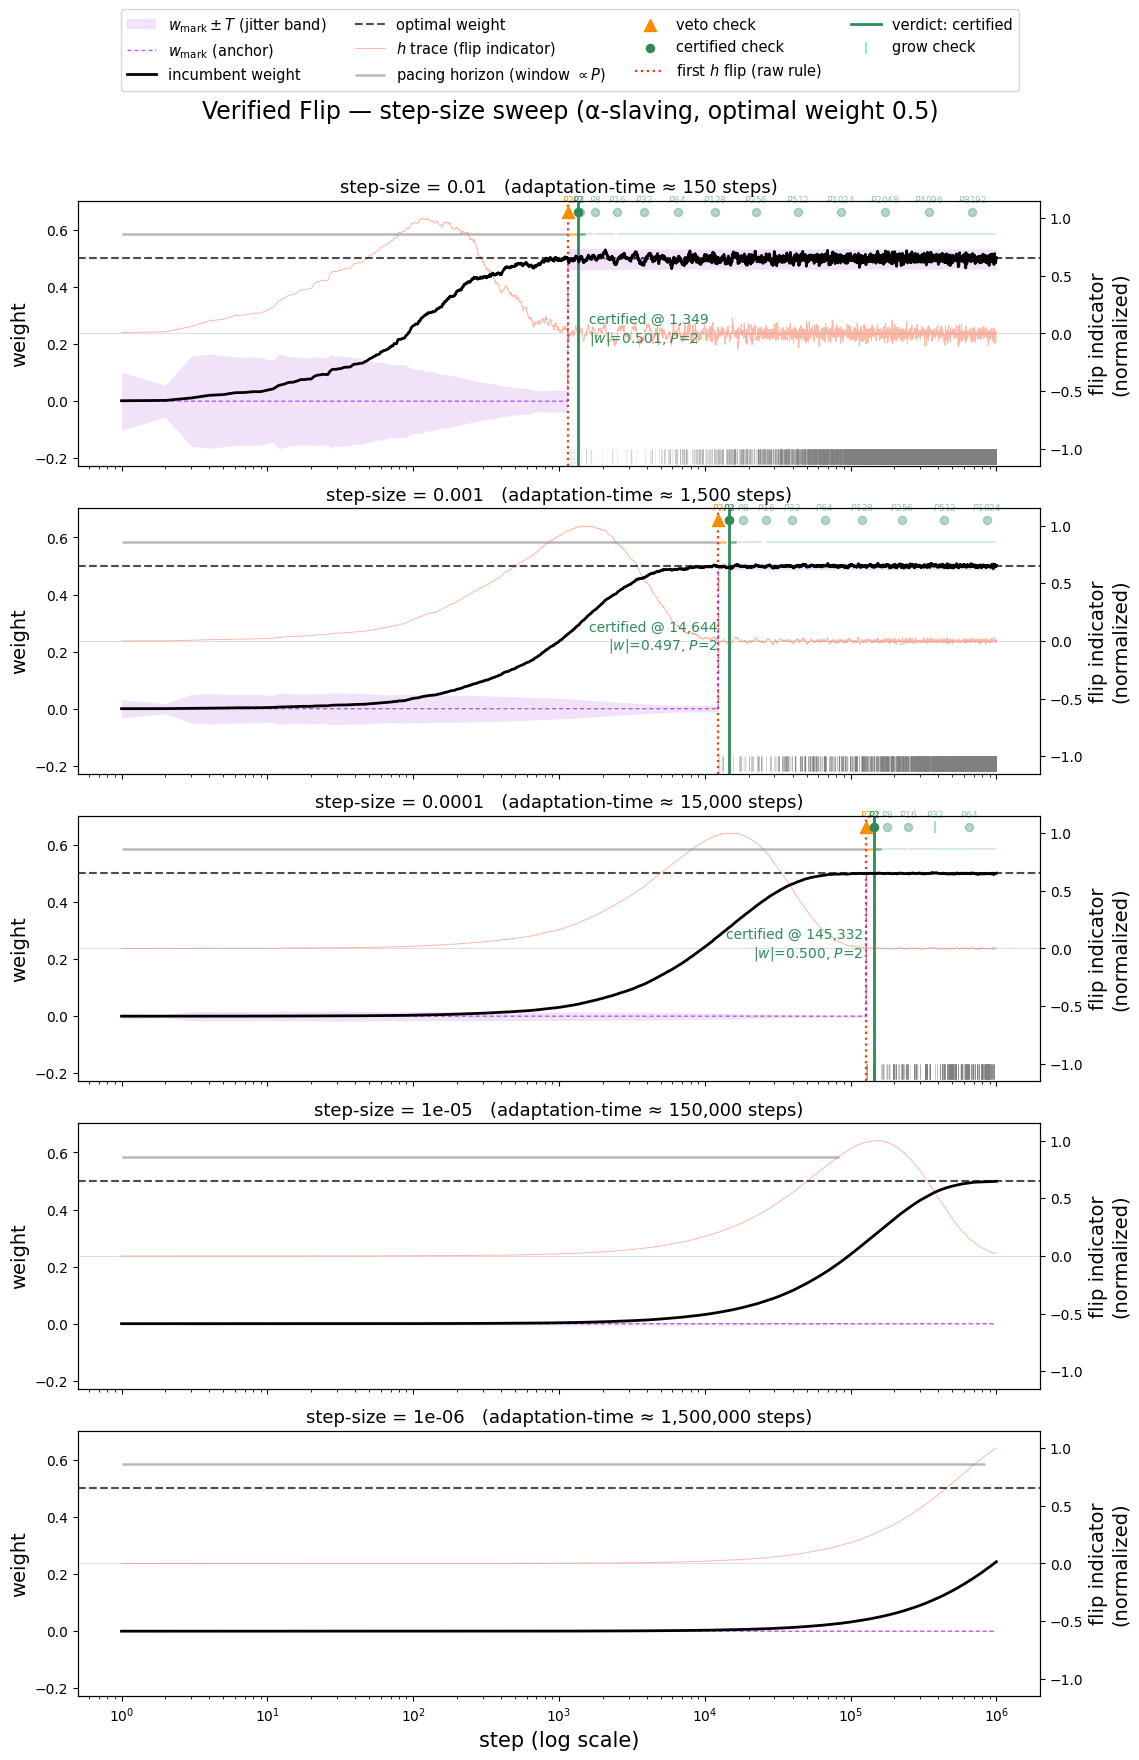

In [5]:
N_STEPS_2 = 1_000_000
OPT_WEIGHT_2 = 0.5
STEP_SIZES = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

res2, titles2 = [], []
for ss in STEP_SIZES:
    feats, targ = make_problem_data(N_STEPS_2, [OPT_WEIGHT_2], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    res2.append(run_verified_flip(feats, targ, step_size=ss))
    titles2.append(f'step-size = {ss:g}   (adaptation-time ≈ {1/(2*ss*(1/3)):,.0f} steps)')

print_summary([f'ss={ss:g}' for ss in STEP_SIZES], res2)
fig = stack_panels(res2, titles2, w_opts=OPT_WEIGHT_2,
                   suptitle='Verified Flip — step-size sweep (α-slaving, optimal weight 0.5)')
plt.show()

## Experiment 3 — blocking by an established feature

Two colinear features (noisy views of *one* signal). An **established** feature starts at its solo optimum; a clean **incumbent** learns from a zero weight and must compete for the shared signal (500k steps, step-size 0.01). The established feature's noise $c$ is swept, and tenure/prune compares the incumbent weight to the established weight.

- **$c = 1.0$ / $0.5$** (weak / partial block): the incumbent's motion is fast enough to be seen within the first horizons → vetoes fire (watch $P$ double), and it correctly **tenures** once the weight settles.
- **$c = 0.0$** (identical twin): the established feature already explains everything, so the incumbent stays at $0$ → correctly **prunes**.
- **$c = 0.1$ — the hard case.** ⚠️ Faithfully implemented, the minimal method **certifies-prune at $\approx 100$ steps**, *before* the blocked drift is visible. By the first check ($\approx$ one adaptation-time) the incumbent has moved only $\sim 0.003$ — inside the jitter band — so $2|D| \le T$ fires. The drift becomes statistically visible only a few horizons later: the faint **shadow vetoes** (with $P$ climbing $2, 4, 8, \dots$) show it being caught *after* the premature verdict, and the incumbent does climb to $0.5$. This is exactly the spec's stated **Known limit** — *"a drift slower than the deepest window examined certifies as converged"* — because the one-window protected childhood is shorter than this drift needs, and the shared-patience prior that would fix it is deliberately omitted from this version. **$c = 0.01$** is the same story, slower still.

                      case |  h flip | veto grow | verdict
----------------------------------------------------------------------------------------
                   c_est=1 |     912 |    1    0 | tenure @ 1,100 (|w|=0.487, P=2)
                 c_est=0.5 |    1366 |    2    0 | tenure @ 2,319 (|w|=0.482, P=4)
                 c_est=0.1 |      13 |    0    0 | prune @ 95 (|w|=0.003, P=1)
                c_est=0.01 |      13 |    0    0 | prune @ 97 (|w|=0.002, P=1)
                   c_est=0 |      66 |    0    0 | prune @ 97 (|w|=0.002, P=1)


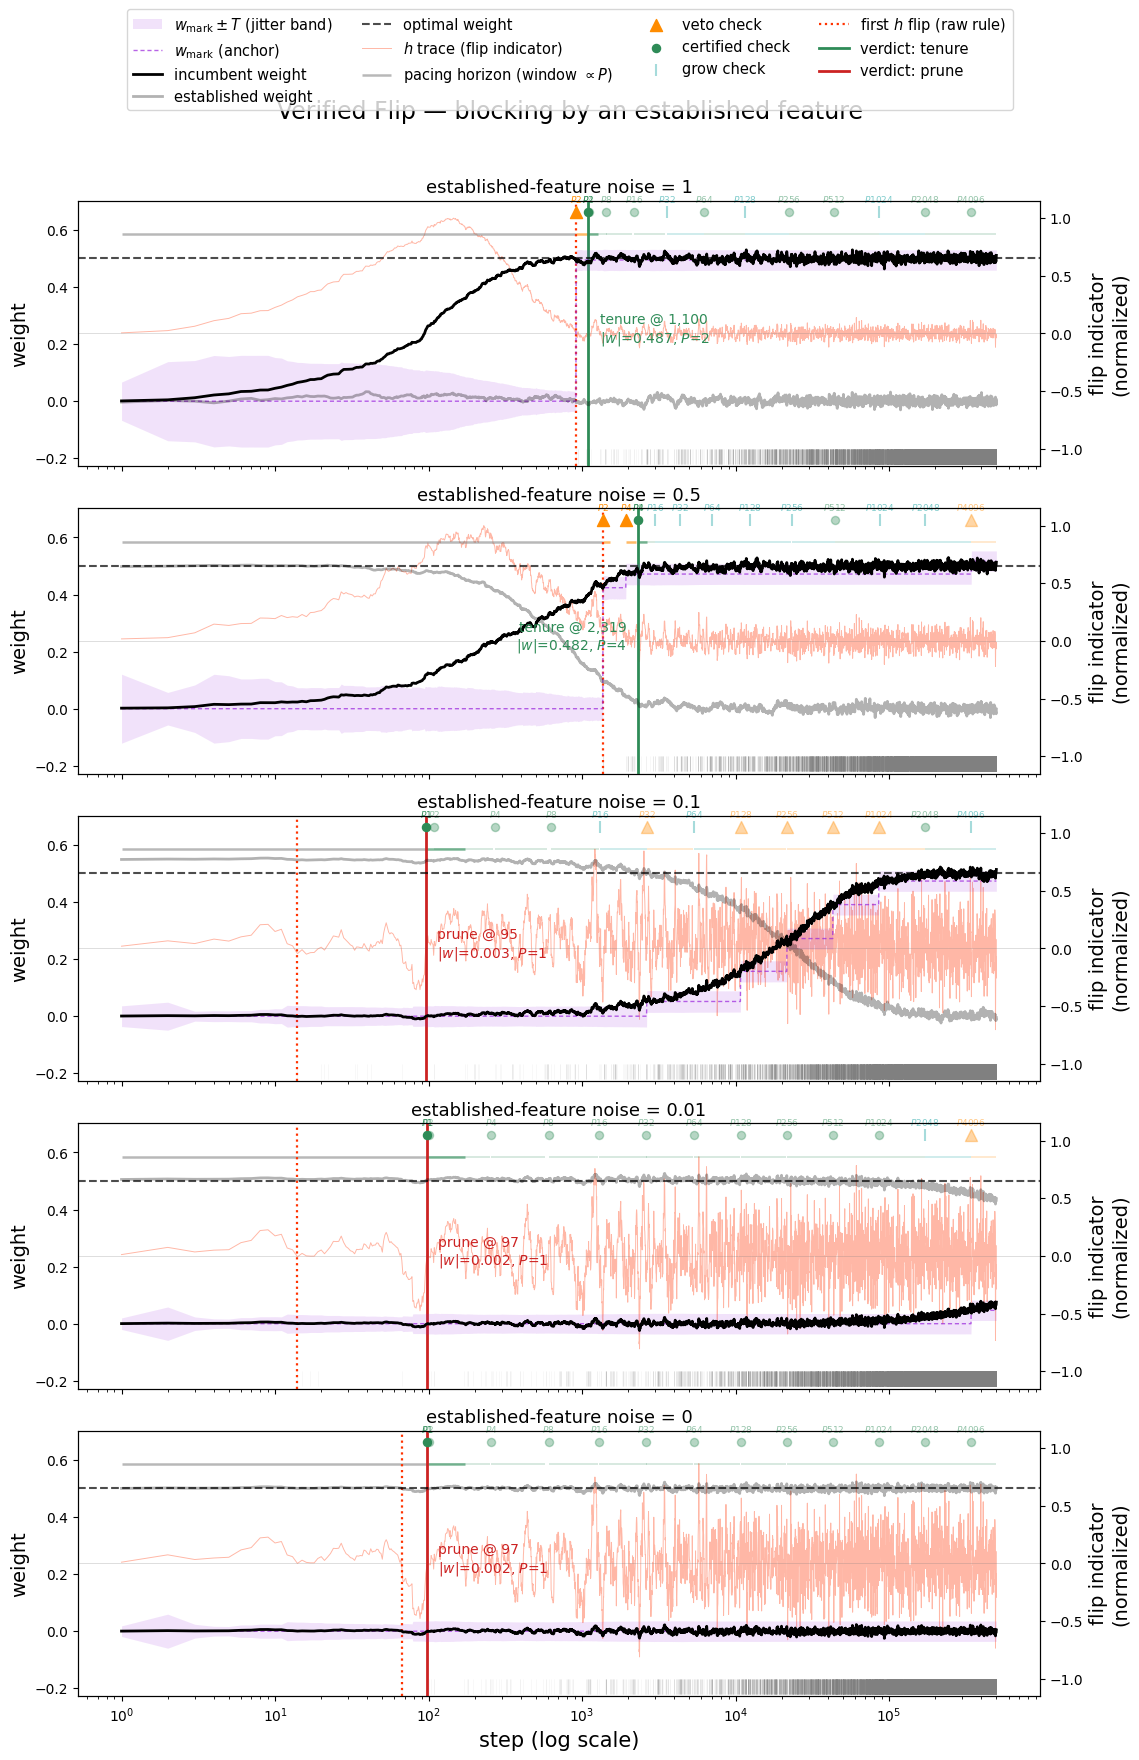

In [6]:
N_STEPS_3 = 500_000
EST_NOISES = [1.0, 0.5, 0.1, 0.01, 0.0]

res3, titles3 = [], []
for c_est in EST_NOISES:
    feats, targ = make_problem_data(
        N_STEPS_3, [W_TEACHER, 0.0], feature_noise=[c_est, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=0)
    w_est0 = optimal_weight(W_TEACHER, c_est)   # established starts at its solo optimum
    res3.append(run_verified_flip(feats, targ, step_size=0.01, w_init=[w_est0, 0.0]))
    titles3.append(f'established-feature noise = {c_est:g}')

print_summary([f'c_est={c:g}' for c in EST_NOISES], res3)
fig = stack_panels(res3, titles3, w_opts=optimal_weight(W_TEACHER, INCUMBENT_NOISE),
                   suptitle='Verified Flip — blocking by an established feature')
plt.show()

## Summary

- **$\alpha$-slaving holds** (exp 1–2): with no constant retuned — and now with **no `beta`** either — the verdict tracks genuine convergence and its timing scales like $1/\alpha$ across six orders of magnitude of step-size. On the single clean feature the method is essentially invisible, as intended.
- **Clear cases work** (exp 3, $c \in \{0, 0.5, 1.0\}$): unblocked / partially-blocked features tenure once the weight settles (with patience $P$ doubling on each veto); the redundant identical twin prunes.
- **The known limit bites at $c = 0.1$** (and $0.01$): a drift slower than the first horizon certifies as converged *before* it materialises. The shadow checks confirm the drift is real and *would* be caught given a longer protected childhood — precisely the motivation for the shared-patience prior this minimal version deliberately leaves out.